# Mann Whitney test analysis (for heart 23)

This analysis will determine what specific features are driving the difference between the two outlier wells in heart 23 versus two random wells in the "normal" population.

In [1]:
import pandas as pd
import pathlib
import random

# for Mann-Whitney U test
from scipy.stats import mannwhitneyu

# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure reproducibility of selected wells
random.seed(0)

In [2]:
# Set plate to process
plate_to_process = "redo"  # options: "redo" and "original"

# Set output directory for figures based on plate to process
if plate_to_process == "redo":
    output_dir = pathlib.Path("./figures/mann_u_analysis/redo_DMSO_plate")
    output_dir.mkdir(parents=True, exist_ok=True)
elif plate_to_process == "original":
    output_dir = pathlib.Path("./figures/mann_u_analysis/original_DMSO_plate")
    output_dir.mkdir(parents=True, exist_ok=True)

# Build a resolved base directory for repository (one level up from current notebook)
base_dir = pathlib.Path.cwd().parent.resolve()

# Directory containing single-cell feature-selected parquet files
sc_dir = base_dir / "." / "3.preprocessing_profiles" / "data" / "single_cell_profiles"

if plate_to_process == "redo":
    fname = "CARD-CelIns-CX7_251110170001_sc_feature_selected.parquet"
elif plate_to_process == "original":
    fname = "CARD-CelIns-CX7_251023130003_sc_feature_selected.parquet"
else:
    raise ValueError(f"Unknown plate_to_process: {plate_to_process}")

# Construct full path and ensure it exists (resolve with strict to raise if missing)
try:
    data_path = (sc_dir / fname).resolve(strict=True)
except Exception as e:
    raise FileNotFoundError(f"Could not resolve path for {fname} in {sc_dir}: {e}")

# Load parquet
single_cell_data = pd.read_parquet(data_path)
print("Loaded single-cell data from:", data_path)

Loaded single-cell data from: /home/jenna/predicting_cardiac_fibrosis_etiologies/3.preprocessing_profiles/data/single_cell_profiles/CARD-CelIns-CX7_251110170001_sc_feature_selected.parquet


Based on the well-level correlation heatmaps, we know wells `C10` and `F09` are outliers. We will select two random wells to compare with.

In [3]:
# Separate out only single-cells from heart #23
single_cells_heart_23 = single_cell_data[
    (single_cell_data["Metadata_heart_number"] == 23)
]
print(f"Number of single cells from Heart #23: {len(single_cells_heart_23)}")

Number of single cells from Heart #23: 994


In [4]:
# From the heart 23 cells, separate out wells C10 and F09 as outlier wells in the same dataframe
outlier_wells = single_cells_heart_23[
    (single_cells_heart_23["Metadata_Well"].isin(["C10", "F09"]))
]
print(f"Number of outlier well cells from Heart #23: {len(outlier_wells)}")

# Select two random wells that are not outlier wells and create dataframe with just those single-cells
non_outlier_wells = (
    single_cells_heart_23[
        (~single_cells_heart_23["Metadata_Well"].isin(["C10", "F09"]))
    ]["Metadata_Well"]
    .unique()
    .tolist()
)
random_wells = random.sample(non_outlier_wells, 2)
random_well_cells = single_cells_heart_23[
    (single_cells_heart_23["Metadata_Well"].isin(random_wells))
]
print(f"Selected random wells: {random_wells}")
print(f"Number of random well cells from Heart #23: {len(random_well_cells)}")

Number of outlier well cells from Heart #23: 273
Selected random wells: ['E06', 'G02']
Number of random well cells from Heart #23: 251


In [5]:
# Perform Mann–Whitney U test on each feature between outlier wells and random wells
mw_results = {}
for feature in single_cell_data.columns:
    if feature.startswith("Metadata_"):
        continue  # Skip metadata columns
    outlier_data = outlier_wells[feature].dropna()
    random_data = random_well_cells[feature].dropna()
    if len(outlier_data) > 0 and len(random_data) > 0:
        u_stat, p_value = mannwhitneyu(
            outlier_data, random_data, alternative="two-sided"
        )
        mw_results[feature] = (u_stat, p_value)

# Create dataframe with results of Mann–Whitney U test with feature names included as column
mw_df = (
    pd.DataFrame.from_dict(
        mw_results, orient="index", columns=["U_Statistic", "P_Value"]
    )
    .reset_index()
    .rename(columns={"index": "Feature"})
)

# Print head
print("Mann-Whitney U Test Results (first 5 features):")
mw_df.head()

Mann-Whitney U Test Results (first 5 features):


,Feature,U_Statistic,P_Value
0,Cytoplasm_AreaShape_Eccentricity,34046.0,0.901177
1,Cytoplasm_AreaShape_MajorAxisLength,33796.0,0.788266
2,Cytoplasm_AreaShape_MaximumRadius,35958.5,0.327173
3,Cytoplasm_AreaShape_Orientation,35907.0,0.342073
4,Cytoplasm_AreaShape_Zernike_2_0,36032.0,0.306653


In [6]:
# Split feature into multiple columns based on underscore delimiter
mw_df_split = mw_df["Feature"].str.split("_", expand=True)
mw_df_split.columns = [
    "Compartment",
    "Feature_Type",
    "Measurement",
    "Organelle",
    "Organelle_2",
    "Parameter1",
    "Parameter2",
]

# If Organelle is not Hoechst, Actin, ER, Mito, or PM, change to "Other"
mw_df_split["Organelle"] = mw_df_split["Organelle"].apply(
    lambda x: x if x in ["Hoechst", "Actin", "ER", "Mitochondria", "PM"] else "Other"
)

# Change Hoechst to Nuclei in Organelle column
mw_df_split["Organelle"] = mw_df_split["Organelle"].replace({"Hoechst": "Nuclei"})

# Combine split columns back to mw_df
mw_df = pd.concat([mw_df, mw_df_split], axis=1)

# Print mw_df head after adding split columns
print("Mann-Whitney U Test Results with Split Columns (first 5 features):")
mw_df.head()

Mann-Whitney U Test Results with Split Columns (first 5 features):


,Feature,U_Statistic,P_Value,Compartment,Feature_Type,Measurement,Organelle,Organelle_2,Parameter1,Parameter2
0,Cytoplasm_AreaShape_Eccentricity,34046.0,0.901177,Cytoplasm,AreaShape,Eccentricity,Other,None,None,None
1,Cytoplasm_AreaShape_MajorAxisLength,33796.0,0.788266,Cytoplasm,AreaShape,MajorAxisLength,Other,None,None,None
2,Cytoplasm_AreaShape_MaximumRadius,35958.5,0.327173,Cytoplasm,AreaShape,MaximumRadius,Other,None,None,None
3,Cytoplasm_AreaShape_Orientation,35907.0,0.342073,Cytoplasm,AreaShape,Orientation,Other,None,None,None
4,Cytoplasm_AreaShape_Zernike_2_0,36032.0,0.306653,Cytoplasm,AreaShape,Zernike,Other,0,None,None


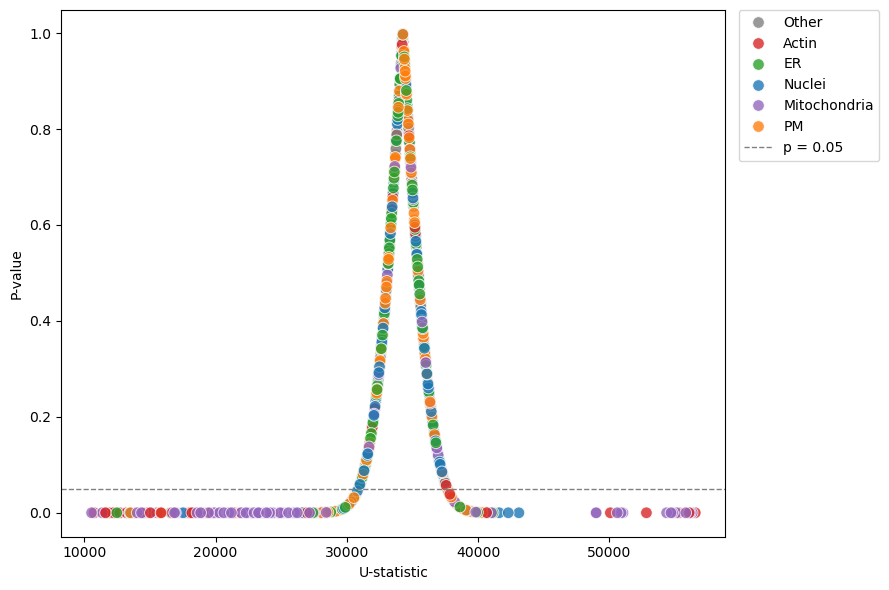

In [7]:
# Set palette
palette = {
    "Nuclei": "tab:blue",
    "Actin": "tab:red",
    "ER": "tab:green",
    "Mitochondria": "tab:purple",
    "PM": "tab:orange",
    "Other": "gray",
}

# Scatterplot of KS statistic (x) vs P-value (y), colored by Organelle
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=mw_df,
    x="U_Statistic",
    y="P_Value",
    hue="Organelle",
    palette=palette,
    alpha=0.8,
    edgecolor="w",
    s=70,
)
plt.xlabel("U-statistic")
plt.ylabel("P-value")
plt.axhline(0.05, color="gray", linestyle="--", linewidth=1, label="p = 0.05")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig(
    pathlib.Path(output_dir) / "mann_whitney_u_test_scatterplot_by_organelle.png",
    dpi=500,
)
plt.show()

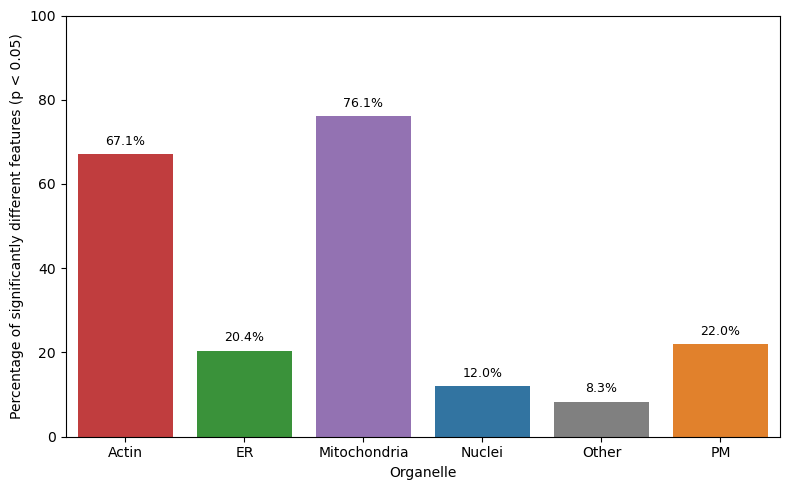

In [8]:
# Compute percentages
significant_features = mw_df[mw_df["P_Value"] < 0.05]
organelle_counts = mw_df["Organelle"].value_counts()
significant_counts = significant_features["Organelle"].value_counts()
percentage_significant = (significant_counts / organelle_counts * 100).fillna(0)

# Convert to dataframe for seaborn
df_pct = percentage_significant.reset_index()
df_pct.columns = ["Organelle", "Percentage"]

# Plot using hue=Organelle to satisfy seaborn's API, then remove the legend
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_pct,
    x="Organelle",
    y="Percentage",
    hue="Organelle",  # avoid FutureWarning by assigning hue
    dodge=False,
    palette=palette,
)
ax.set_ylabel("Percentage of significantly different features (p < 0.05)")
ax.set_xlabel("Organelle")
ax.set_ylim(0, 100)

# Add percentage labels above each bar
for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + 1.5,  # offset above the bar
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
    )

if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.tight_layout()
plt.savefig(
    pathlib.Path(output_dir)
    / "mann_whitney_u_test_percentage_significant_features_by_organelle.png",
    dpi=500,
)
plt.show()